# Experiment: 03 MATH-500 Stratification

Objective:
- Compare entropy vs combined AUC by difficulty and subject for Qwen and DeepSeek.
- Highlight where geometry gains are stable versus noisy.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [2]:
qwen_math = vu.load_result_json("qwen", "math500")
deepseek_math = vu.load_result_json("deepseek", "math500")

difficulty_rows = vu.collect_difficulty_rows("qwen", qwen_math) + vu.collect_difficulty_rows("deepseek", deepseek_math)
subject_rows = vu.collect_subject_rows("qwen", qwen_math) + vu.collect_subject_rows("deepseek", deepseek_math)

difficulty_order = ["level_1", "level_2", "level_3", "level_4", "level_5", "easy_1-2", "medium_3", "hard_4-5"]
subject_order = [
    "Algebra",
    "Counting & Probability",
    "Geometry",
    "Intermediate Algebra",
    "Number Theory",
    "Prealgebra",
    "Precalculus",
]

def select(rows: list[dict], model: str, key: str, value: str) -> dict:
    for row in rows:
        if row["model"] == model and row[key] == value:
            return row
    raise KeyError((model, key, value))


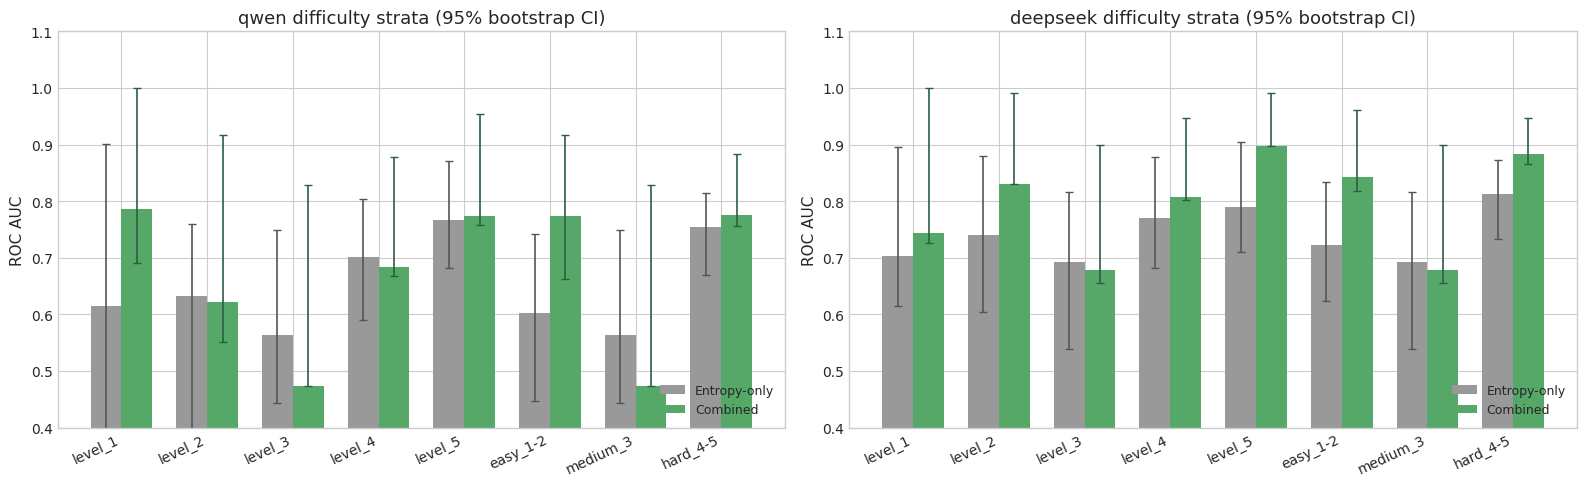

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(difficulty_order))
width = 0.36

for ax_idx, model in enumerate(["qwen", "deepseek"]):
    rows_d = [select(difficulty_rows, model, "bucket", b) for b in difficulty_order]
    entropy = np.array([r["entropy_auc"] for r in rows_d])
    combined = np.array([r["combined_auc"] for r in rows_d])

    # Bootstrap CIs for combined and entropy (asymmetric: bars from low to high)
    ent_lo = np.array([r["entropy_ci_low"] for r in rows_d])
    ent_hi = np.array([r["entropy_ci_high"] for r in rows_d])
    comb_lo = np.array([r["combined_ci_low"] for r in rows_d])
    comb_hi = np.array([r["combined_ci_high"] for r in rows_d])

    ent_err = np.array([entropy - ent_lo, ent_hi - entropy])
    comb_err = np.array([combined - comb_lo, comb_hi - combined])

    # Clamp negative error magnitudes (can happen at boundaries)
    ent_err = np.clip(ent_err, 0, None)
    comb_err = np.clip(comb_err, 0, None)

    axes[ax_idx].bar(x - width / 2, entropy, width=width, label="Entropy-only", color="#999999",
                     yerr=ent_err, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "#555555"})
    axes[ax_idx].bar(x + width / 2, combined, width=width, label="Combined", color="#55A868",
                     yerr=comb_err, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "#2A6040"})
    axes[ax_idx].set_title(f"{model} difficulty strata (95% bootstrap CI)")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(difficulty_order, rotation=25, ha="right")
    axes[ax_idx].set_ylabel("ROC AUC")
    axes[ax_idx].set_ylim(0.4, 1.1)
    axes[ax_idx].legend(loc="lower right")

fig.tight_layout()
plt.show()


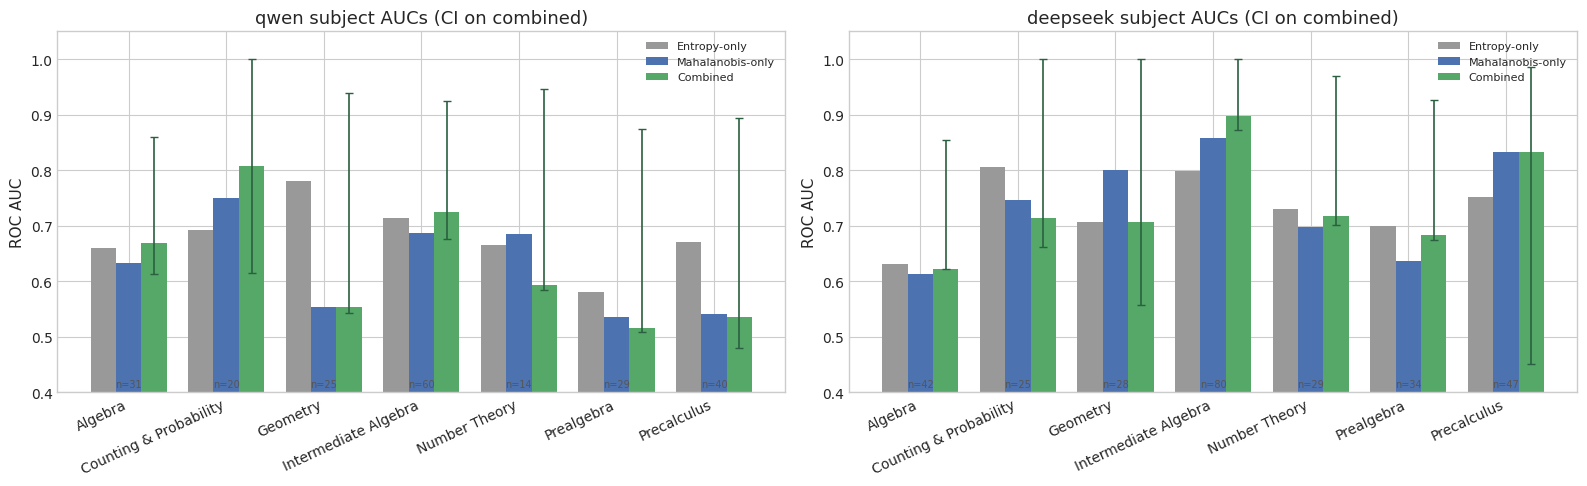

In [4]:
# Subject plot: grouped bars (entropy, mahal, combined) with CI on combined.
# Grouped view makes it easier to see whether mahal or combined drives the delta.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(subject_order))
width = 0.26

for ax_idx, model in enumerate(["qwen", "deepseek"]):
    rows_s = [select(subject_rows, model, "subject", s) for s in subject_order]
    entropy = np.array([r["entropy_auc"] for r in rows_s])
    mahal = np.array([r["mahal_auc"] for r in rows_s])
    combined = np.array([r["combined_auc"] for r in rows_s])
    counts = [r["n_incorrect"] for r in rows_s]

    comb_lo = np.array([r["combined_ci_low"] for r in rows_s])
    comb_hi = np.array([r["combined_ci_high"] for r in rows_s])
    comb_err = np.clip(np.array([combined - comb_lo, comb_hi - combined]), 0, None)

    axes[ax_idx].bar(x - width, entropy, width=width, label="Entropy-only", color="#999999")
    axes[ax_idx].bar(x, mahal, width=width, label="Mahalanobis-only", color="#4C72B0")
    axes[ax_idx].bar(x + width, combined, width=width, label="Combined", color="#55A868",
                     yerr=comb_err, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "#2A6040"})

    axes[ax_idx].set_title(f"{model} subject AUCs (CI on combined)")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(subject_order, rotation=25, ha="right")
    axes[ax_idx].set_ylabel("ROC AUC")
    axes[ax_idx].set_ylim(0.4, 1.05)
    axes[ax_idx].legend(loc="upper right", fontsize=8)
    for xi, ci in zip(x, counts):
        axes[ax_idx].text(xi, 0.41, f"n={ci}", ha="center", fontsize=7, color="#555555")

fig.tight_layout()
plt.show()
